# Results — Performance Comparison

Bar charts, violin plots and statistical comparisons for all methods evaluated on the fish oil dataset.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path('../results/fish_oil')

# ── Load all results into a flat dataframe ────────────────────────────────────
rows = []

# CNN conditions
cnn = json.loads((RESULTS_DIR / 'chroma_results.json').read_text())
for cond, metrics in cnn.items():
    label = 'ChromaCNN (pretrain)' if cond == 'chroma_pretrain' else 'ChromaCNN (scratch)'
    for v in metrics['balanced_accuracy']:
        rows.append({'method': label, 'representation': '2D chromatogram', 'ba': v})

# Baselines
MODEL_LABEL = {'plsda': 'PLS-DA', 'rf': 'Random Forest', 'svm': 'SVM', 'mlp': 'MLP'}
for rep in ['sum', 'max_proj', 'chroma_pca']:
    data = json.loads((RESULTS_DIR / f'baseline_gcms_{rep}_results.json').read_text())
    for model, metrics in data.items():
        for v in metrics['balanced_accuracy']:
            rows.append({'method': MODEL_LABEL[model], 'representation': rep, 'ba': v})

df = pd.DataFrame(rows)
df['label'] = df['method'] + '\n(' + df['representation'] + ')'

# Summary table
summary = (df.groupby('label')['ba']
             .agg(mean='mean', std='std', n='count')
             .sort_values('mean', ascending=False)
             .reset_index())
print(summary.to_string(index=False))

                                  label     mean      std  n
ChromaCNN (pretrain)\n(2D chromatogram) 0.951364 0.065939 50
 ChromaCNN (scratch)\n(2D chromatogram) 0.759394 0.139526 50
                   PLS-DA\n(chroma_pca) 0.702917 0.092337 50
                   Random Forest\n(sum) 0.696477 0.114371 50
                      SVM\n(chroma_pca) 0.693485 0.109478 50
                        SVM\n(max_proj) 0.531932 0.121069 50
            Random Forest\n(chroma_pca) 0.528902 0.116953 50
                             SVM\n(sum) 0.492841 0.083968 50
                     PLS-DA\n(max_proj) 0.469356 0.107812 50
                          PLS-DA\n(sum) 0.429242 0.114671 50
                        MLP\n(max_proj) 0.395076 0.124632 50
              Random Forest\n(max_proj) 0.381742 0.094549 50
                      MLP\n(chroma_pca) 0.377008 0.160967 50
                             MLP\n(sum) 0.369242 0.126559 50


## 1 — Violin plot: all methods

/var/folders/n1/g9l7c9mx7k56dqzbw551lj280000gn/T/ipykernel_94871/45550801.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y='ba', order=order, ax=ax,
/var/folders/n1/g9l7c9mx7k56dqzbw551lj280000gn/T/ipykernel_94871/45550801.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


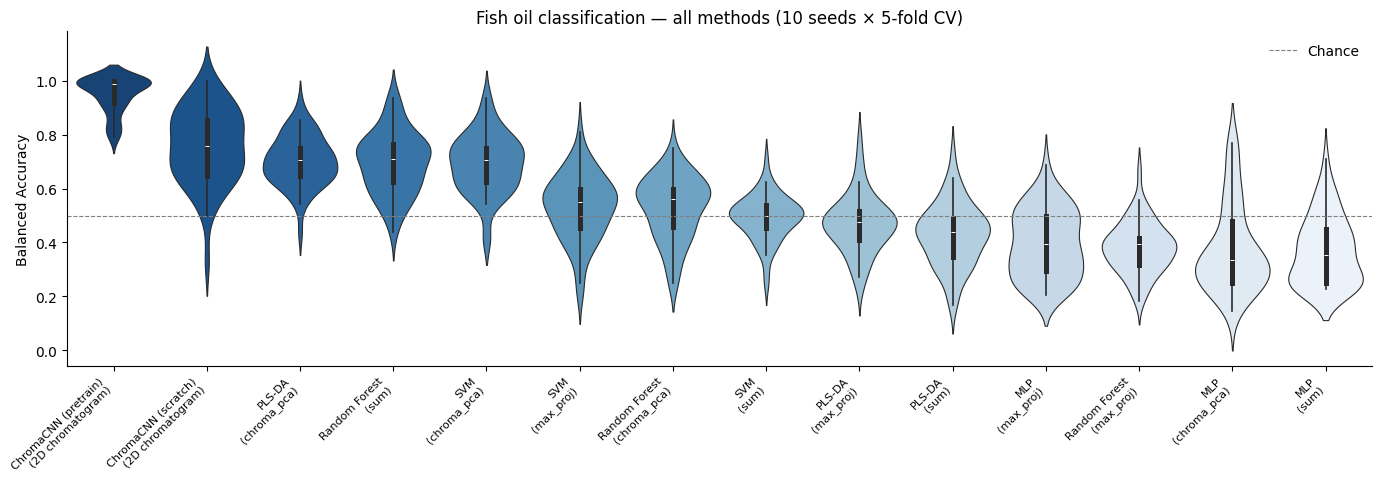

In [2]:
order = summary['label'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(data=df, x='label', y='ba', order=order, ax=ax,
               inner='box', palette='Blues_r', linewidth=0.8)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Chance')
ax.set_xlabel('')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Fish oil classification — all methods (10 seeds × 5-fold CV)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 2 — Ranked bar chart (mean ± 1 SD)

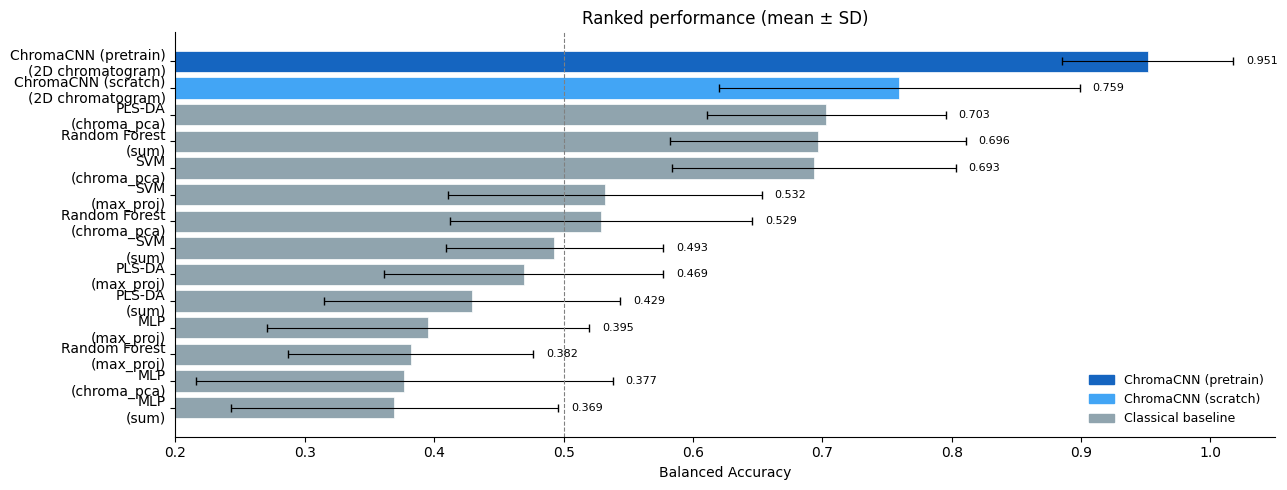

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
colours = ['#1565c0' if 'pretrain' in l else
           '#42a5f5' if 'scratch' in l else '#90a4ae'
           for l in summary['label']]

bars = ax.barh(summary['label'], summary['mean'],
               xerr=summary['std'], color=colours,
               edgecolor='white', linewidth=0.5,
               error_kw=dict(elinewidth=0.8, capsize=3))
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Balanced Accuracy')
ax.set_title('Ranked performance (mean ± SD)')
ax.invert_yaxis()
ax.set_xlim(0.2, 1.05)

# Annotate bars
for i, (mean, std) in enumerate(zip(summary['mean'], summary['std'])):
    ax.text(mean + std + 0.01, i, f'{mean:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
legend = [Patch(color='#1565c0', label='ChromaCNN (pretrain)'),
          Patch(color='#42a5f5', label='ChromaCNN (scratch)'),
          Patch(color='#90a4ae', label='Classical baseline')]
ax.legend(handles=legend, frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 3 — Pretraining lift: scratch vs pretrain

/var/folders/n1/g9l7c9mx7k56dqzbw551lj280000gn/T/ipykernel_94871/4236718998.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([scratch_ba, pretrain_ba], labels=['From scratch', 'Pretrained'],


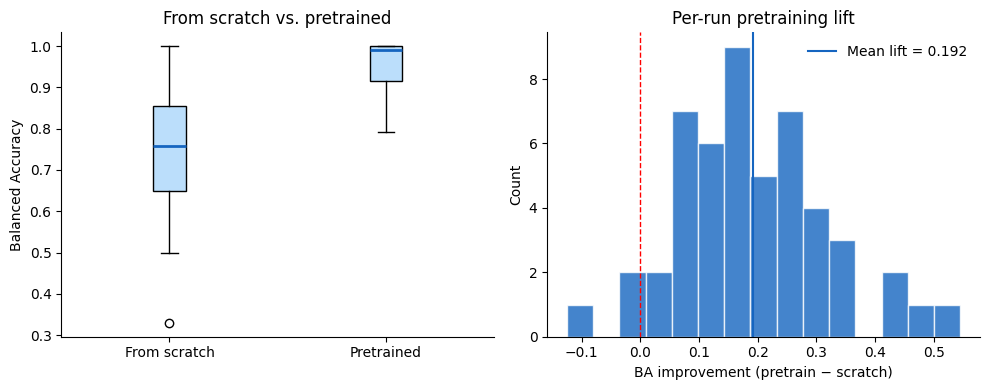

Mann-Whitney U (pretrain > scratch): p = 2.14e-12


In [4]:
scratch_ba  = np.array(cnn['from_scratch']['balanced_accuracy'])
pretrain_ba = np.array(cnn['chroma_pretrain']['balanced_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Side-by-side box
axes[0].boxplot([scratch_ba, pretrain_ba], labels=['From scratch', 'Pretrained'],
                patch_artist=True,
                boxprops=dict(facecolor='#bbdefb'),
                medianprops=dict(color='#1565c0', linewidth=2))
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('From scratch vs. pretrained')
sns.despine(ax=axes[0])

# Per-fold lift (matched pairs)
lift = pretrain_ba - scratch_ba
axes[1].hist(lift, bins=15, color='#1565c0', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].axvline(lift.mean(), color='#1565c0', linestyle='-', linewidth=1.5,
                label=f'Mean lift = {lift.mean():.3f}')
axes[1].set_xlabel('BA improvement (pretrain − scratch)')
axes[1].set_ylabel('Count')
axes[1].set_title('Per-run pretraining lift')
axes[1].legend(frameon=False)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu
u, p = mannwhitneyu(pretrain_ba, scratch_ba, alternative='greater')
print(f'Mann-Whitney U (pretrain > scratch): p = {p:.2e}')